# Customer Churn Prediction

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 21 features

Churn prediction estimates which customers are likely to cancel their subscription. This enables proactive retention strategies, since the cost of retaining a customer is typically much lower than acquiring a new one.

**Pipeline:**
1. EDA — distributions, correlations, churn rate by segment
2. Customer segmentation via K-Means — profiling groups before modeling
3. Baseline (Logistic Regression) → XGBoost / LightGBM comparison
4. Threshold tuning — optimizing for business cost of FP vs FN
5. SHAP — global and local feature importance


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", None)

os.makedirs("data", exist_ok=True)  # Colab: create dir if not exists

URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(URL)

df.to_csv("data/telco_churn.csv", index=False)
print("data/telco_churn.csv [saved]")

# quick sanity check
print(f"\nshape         : {df.shape}")
print(f"churn rate    : {df['Churn'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
print(f"missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head(3)


data/telco_churn.csv [saved]

shape         : (7043, 21)
churn rate    : {'No': 73.5, 'Yes': 26.5}
missing values:
Series([], dtype: int64)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


# 1. Data Cleaning

`TotalCharges` is stored as string in the raw data — a small subset of new customers (tenure = 0) has an empty value instead of 0. Converting and dropping those rows is safe given it affects < 0.2% of the data.

Binary categorical columns (`SeniorCitizen`, `Churn`) are encoded to 0/1 for downstream use.


In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# rows with tenure=0 have blank TotalCharges — drop them
n_before = len(df)
df.dropna(subset=["TotalCharges"], inplace=True)
print(f"Dropped {n_before - len(df)} rows with blank TotalCharges (tenure=0 edge case)")

# encode target
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# column overview
print("\n--- Column types after cleaning ---")
print(df.dtypes.to_string())

print(f"\nFinal shape : {df.shape}")
print(f"Churn rate  : {df['Churn'].mean():.1%}")


Dropped 11 rows with blank TotalCharges (tenure=0 edge case)

--- Column types after cleaning ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64

Final shape : (7032, 21)
Churn rate  : 26.6%


# 2. Exploratory Data Analysis

Key questions:
- Do churners differ in tenure / spend profile? (jointplot — two dims at once)
- Which contract type / internet service drives churn?
- How correlated are the three numeric features?


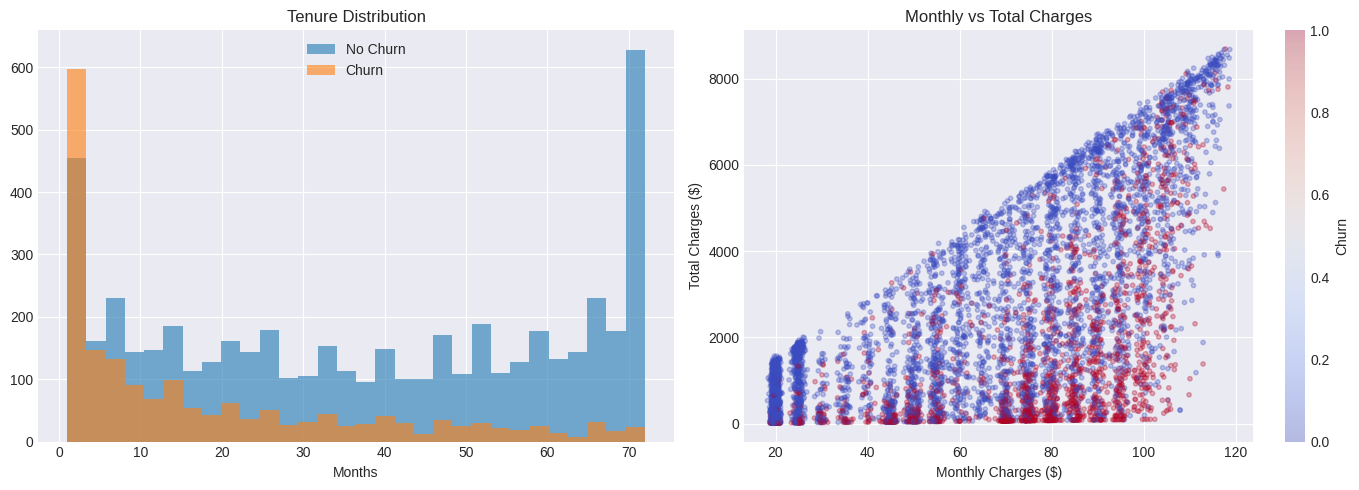

eda_numeric.png [saved]

--- Mean numeric features by churn ---
          tenure  MonthlyCharges  TotalCharges
Churn                                         
No Churn    37.7            61.3        2555.3
Churn       18.0            74.4        1531.8


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution by churn
for label, grp in df.groupby("Churn"):
    lname = "Churn" if label == 1 else "No Churn"
    axes[0].hist(grp["tenure"], bins=30, alpha=0.6, label=lname)
axes[0].set_title("Tenure Distribution")
axes[0].set_xlabel("Months")
axes[0].legend()

# Monthly charges vs total charges — colour = churn
scatter = axes[1].scatter(
    df["MonthlyCharges"], df["TotalCharges"],
    c=df["Churn"], cmap="coolwarm", alpha=0.3, s=10
)
plt.colorbar(scatter, ax=axes[1], label="Churn")
axes[1].set_title("Monthly vs Total Charges")
axes[1].set_xlabel("Monthly Charges ($)")
axes[1].set_ylabel("Total Charges ($)")

plt.tight_layout()
plt.savefig("eda_numeric.png", dpi=120)
plt.show()
print("eda_numeric.png [saved]")

# numeric summary table
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
summary = df.groupby("Churn")[num_cols].mean().round(1)
summary.index = summary.index.map({0: "No Churn", 1: "Churn"})
print("\n--- Mean numeric features by churn ---")
print(summary.to_string())


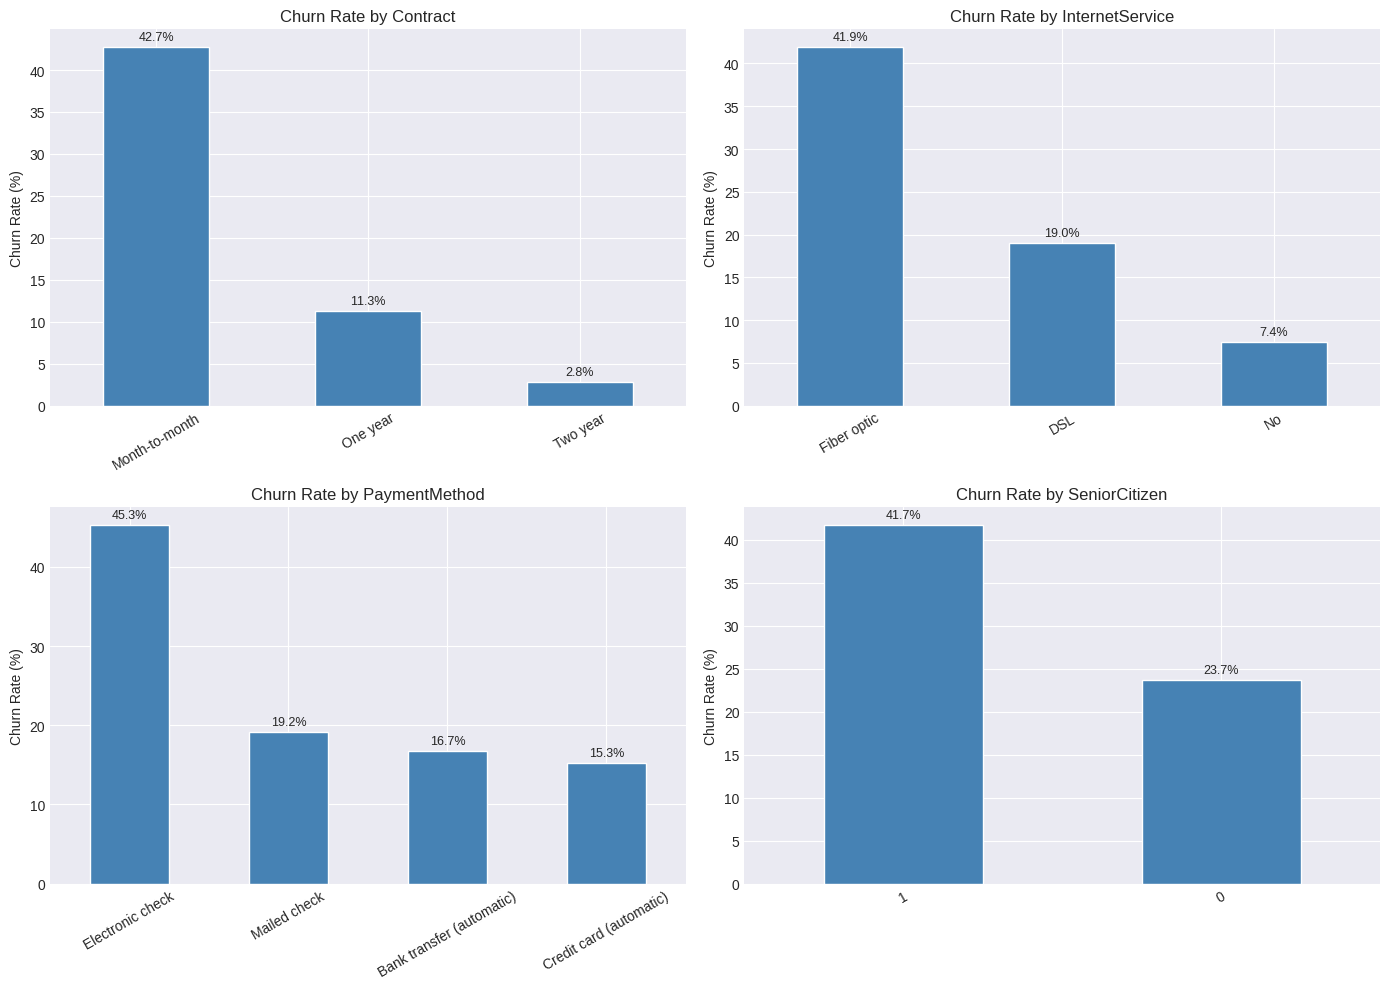

eda_categorical.png [saved]


In [5]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)["Churn"].mean().mul(100).sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)
    # annotate bars
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()
plt.savefig("eda_categorical.png", dpi=120)
plt.show()
print("eda_categorical.png [saved]")


## EDA Key Findings

| Feature | Churners | Non-Churners | Delta |
|---|---|---|---|
| Avg tenure | 18.0 months | 37.7 months | **-52%** |
| Avg monthly charge | $74.4 | $61.3 | **+21%** |
| Avg total charge | $1,531 | $2,555 | **-40%** |

**Contract type** is the strongest single predictor: month-to-month customers churn at 42.7% vs 2.8% for two-year contracts.  
**Fiber optic** service drives churn at 41.9% — likely due to higher monthly cost combined with short tenure.  
**Electronic check** payment correlates with 45.3% churn — possibly linked to higher proportion of month-to-month customers.  
**Senior citizens** churn at 41.7% vs 23.7% — may reflect price sensitivity.

Model implication: `Contract`, `InternetService`, `tenure` and `MonthlyCharges` will likely dominate SHAP importance.


# 3. Preprocessing

Strategy:
- Binary Yes/No columns → 0/1 label encoding (no ordering artifact)
- Multi-class categoricals (`Contract`, `InternetService`, `PaymentMethod`) → one-hot encoding
- Numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) → StandardScaler
- Drop `customerID` (identifier, non-predictive)
- Train/test split: 80/20, stratified on `Churn`


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_model = df.drop(columns=["customerID"])

# binary Yes/No columns → 0/1
binary_cols = [c for c in df_model.columns
               if df_model[c].dtype == "object"
               and set(df_model[c].dropna().unique()).issubset({"Yes", "No"})]
df_model[binary_cols] = (df_model[binary_cols] == "Yes").astype(int)

# remaining categoricals → one-hot
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=17, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]} rows | {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"Churn in train : {y_train.mean():.1%}")
print(f"Churn in test  : {y_test.mean():.1%}")
print(f"\nFeature list ({X.shape[1]} total):")
print(list(X.columns))


Training set : 5625 rows | 30 features
Test set     : 1407 rows
Churn in train : 26.6%
Churn in test  : 26.6%

Feature list (30 total):
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


# 4. Customer Segmentation (K-Means)

Unsupervised clustering before supervised modeling — goal is to identify natural customer groups and verify if churn concentrates in specific segments.  
Optimal k selected by silhouette score (more robust than the elbow on this feature space).  
Clusters visualized with PCA (2 components) to keep interpretability.


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=17, n_init=10)
    km.fit(X_train_sc)
    sil_scores[k] = silhouette_score(X_train_sc, km.labels_, sample_size=2000)

# print as table
print(f"{'k':>4} | {'Silhouette':>12}")
print("-" * 20)
for k, s in sil_scores.items():
    print(f"{k:>4} | {s:>12.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k = {best_k}  (silhouette = {sil_scores[best_k]:.4f})")


   k |   Silhouette
--------------------
   2 |       0.3352
   3 |       0.2221
   4 |       0.2436
   5 |       0.2002
   6 |       0.1972
   7 |       0.1425
   8 |       0.1303

Best k = 2  (silhouette = 0.3352)


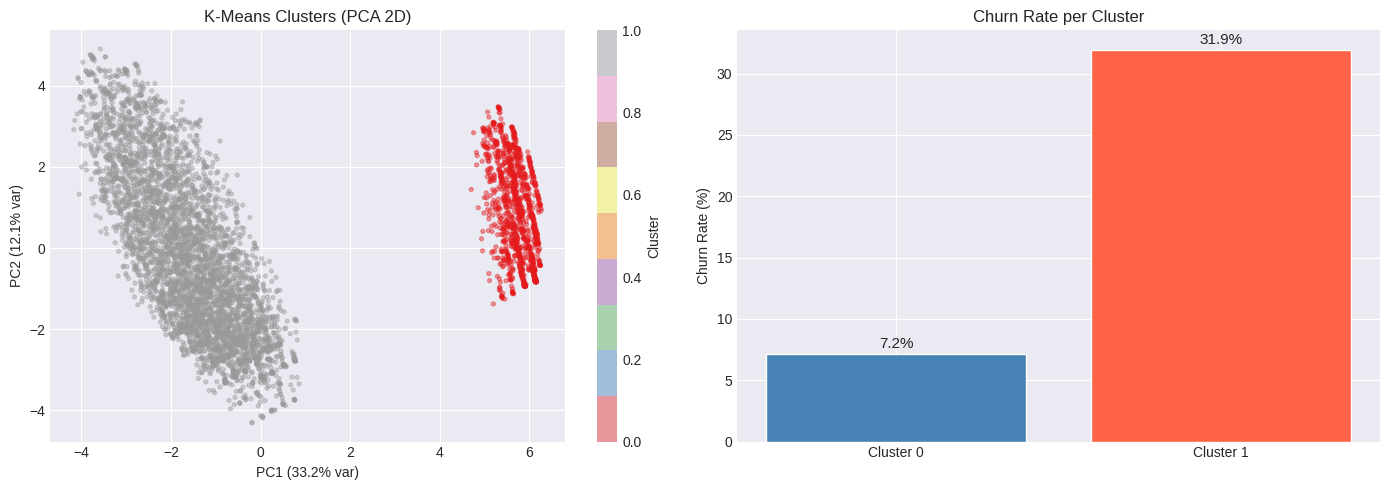

kmeans_clusters.png [saved]

--- Cluster Profile ---
                      tenure  MonthlyCharges  TotalCharges  Churn
Cluster 0 (Stable?)    30.95           21.13        673.86   0.07
Cluster 1 (At-Risk?)   33.06           76.82       2747.27   0.32

Cluster sizes: {1: 4409, 0: 1216}


In [10]:
# fit with best k
km = KMeans(n_clusters=2, random_state=17, n_init=10)
cluster_labels_train = km.fit_predict(X_train_sc)

# PCA 2D for visualization
pca = PCA(n_components=2, random_state=17)
X_pca = pca.fit_transform(X_train_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: cluster membership
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=cluster_labels_train, cmap="Set1",
                           alpha=0.4, s=8)
plt.colorbar(scatter, ax=axes[0], label="Cluster")
axes[0].set_title("K-Means Clusters (PCA 2D)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")

# right: churn rate per cluster
cluster_df = X_train.copy()
cluster_df["cluster"] = cluster_labels_train
cluster_df["Churn"] = y_train.values
churn_by_cluster = cluster_df.groupby("cluster")["Churn"].mean().mul(100)
axes[1].bar(["Cluster 0", "Cluster 1"], churn_by_cluster.values,
            color=["steelblue", "tomato"], edgecolor="white")
for i, v in enumerate(churn_by_cluster.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)
axes[1].set_title("Churn Rate per Cluster")
axes[1].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=120)
plt.show()
print("kmeans_clusters.png [saved]")

# numeric profile table
profile = cluster_df.groupby("cluster")[
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].mean().round(2)
profile.index = ["Cluster 0 (Stable?)", "Cluster 1 (At-Risk?)"]
print("\n--- Cluster Profile ---")
print(profile.to_string())
print(f"\nCluster sizes: {cluster_df['cluster'].value_counts().to_dict()}")


## Clustering Findings

| | Cluster 0 — "Basic" | Cluster 1 — "High-Spend" |
|---|---|---|
| Size | 1,216 (21.6%) | 4,409 (78.4%) |
| Avg monthly charge | $21.13 | $76.82 |
| Avg total charge | $673 | $2,747 |
| **Churn rate** | **7.2%** | **31.9%** |

The primary split is driven by monthly spend (PC1 = 33.2% variance). Cluster 1 likely corresponds to customers with fiber optic + add-on services — high ARPU but 4.4× higher churn risk. Retention efforts should concentrate here.


# 5. Modeling

Baseline: Logistic Regression (interpretable, fast).  
Main models: XGBoost, LightGBM — compared at default threshold (0.5).  
Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC.  
Note: with 26.6% churn, recall matters more than accuracy — missing a churner is costlier than a false alarm.


=== Logistic Regression (baseline) ===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.73      1407
weighted avg       0.79      0.80      0.80      1407

ROC-AUC : 0.8446
FP (false alarms)   : 117
FN (missed churners): 163


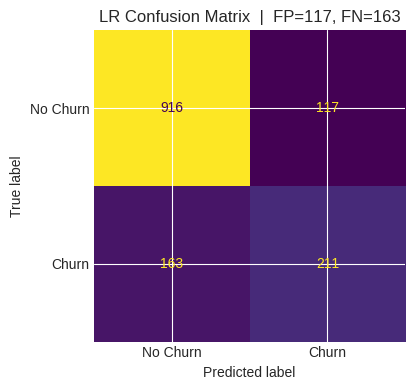

cm_lr.png [saved]


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)

lr = LogisticRegression(max_iter=1000, random_state=17)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()

print("=== Logistic Regression (baseline) ===")
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC : {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"FP (false alarms)   : {fp}")
print(f"FN (missed churners): {fn}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=ax, colorbar=False)
ax.set_title(f"LR Confusion Matrix  |  FP={fp}, FN={fn}")
plt.tight_layout()
plt.savefig("cm_lr.png", dpi=120)
plt.show()
print("cm_lr.png [saved]")


In [12]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

models = {
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        scale_pos_weight=3,  # handles class imbalance
        random_state=17, eval_metric="logloss", verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        class_weight="balanced",
        random_state=17, verbose=-1
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results[name] = {
        "accuracy":  (tp + tn) / len(y_test),
        "precision": tp / (tp + fp),
        "recall":    tp / (tp + fn),
        "f1":        2*tp / (2*tp + fp + fn),
        "auc":       roc_auc_score(y_test, y_prob),
        "fp": fp, "fn": fn
    }

# add LR baseline to compare
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()
results["LogReg (baseline)"] = {
    "accuracy": (tp+tn)/len(y_test), "precision": tp/(tp+fp),
    "recall": tp/(tp+fn), "f1": 2*tp/(2*tp+fp+fn),
    "auc": roc_auc_score(y_test, y_prob_lr),
    "fp": fp, "fn": fn
}

# comparison table
print(f"{'Model':<22} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>7} {'FP':>5} {'FN':>5}")
print("-" * 70)
for name, r in results.items():
    print(f"{name:<22} {r['accuracy']:>6.3f} {r['precision']:>6.3f} "
          f"{r['recall']:>6.3f} {r['f1']:>6.3f} {r['auc']:>7.4f} "
          f"{r['fp']:>5} {r['fn']:>5}")


Model                     Acc   Prec    Rec     F1     AUC    FP    FN
----------------------------------------------------------------------
XGBoost                 0.748  0.518  0.789  0.625  0.8435   275    79
LightGBM                0.762  0.538  0.738  0.622  0.8421   237    98
LogReg (baseline)       0.801  0.643  0.564  0.601  0.8446   117   163


## Model Comparison at Default Threshold (0.5)

| Model | Recall | FN (missed churners) | FP (false alarms) | AUC |
|---|---|---|---|---|
| XGBoost | 78.9% | 79 | 275 | 0.8435 |
| LightGBM | 73.8% | 98 | 237 | 0.8421 |
| LogReg (baseline) | 56.4% | 163 | 117 | 0.8446 |

All models have nearly identical AUC — discriminative ability is equivalent.  
The threshold choice determines the FP/FN trade-off.

# 6. Threshold Tuning

**Business assumption:** missing a churner (FN) costs 5× more than a false retention offer (FP).  
This reflects typical CLV (Customer Lifetime Value) reasoning — losing a customer permanently is far more expensive than sending an unnecessary discount.

We minimize: `total_cost = 5 × FN + 1 × FP`


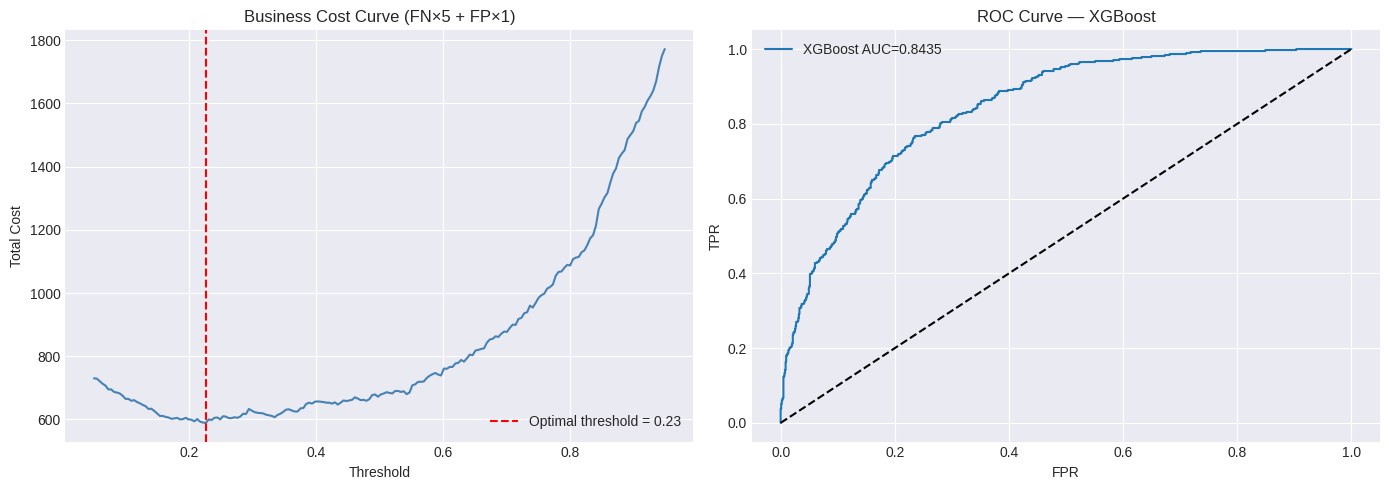

threshold_tuning.png [saved]

Optimal threshold : 0.23

Metric                Default (0.50)     Optimal (0.23)
--------------------------------------------------------
Recall                         78.9%              93.9%
Precision                      51.8%              42.5%
FP                               275                474
FN                                79                 23
Total cost                       670                589


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

xgb_model = models["XGBoost"]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# business cost per threshold
thresholds = np.linspace(0.05, 0.95, 200)
costs, fps_list, fns_list = [], [], []
FN_COST, FP_COST = 5, 1

for t in thresholds:
    preds = (y_prob_xgb >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    costs.append(FN_COST * fn + FP_COST * fp)
    fps_list.append(fp); fns_list.append(fn)

best_idx = np.argmin(costs)
best_t   = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: cost curve
axes[0].plot(thresholds, costs, color="steelblue")
axes[0].axvline(best_t, color="red", linestyle="--",
                label=f"Optimal threshold = {best_t:.2f}")
axes[0].set_title(f"Business Cost Curve (FN×{FN_COST} + FP×{FP_COST})")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Total Cost")
axes[0].legend()

# right: ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
ax = axes[1]
ax.plot(fpr, tpr, label=f"XGBoost AUC={auc(fpr,tpr):.4f}")
ax.plot([0,1],[0,1],"k--")
ax.set_title("ROC Curve — XGBoost")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend()

plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=120)
plt.show()
print("threshold_tuning.png [saved]")

# metrics at optimal threshold
y_pred_opt = (y_prob_xgb >= best_t).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()

print(f"\nOptimal threshold : {best_t:.2f}")
print(f"\n{'Metric':<20} {'Default (0.50)':>15} {'Optimal ({:.2f})'.format(best_t):>18}")
print("-" * 56)
print(f"{'Recall':<20} {'78.9%':>15} {tp/(tp+fn)*100:>17.1f}%")
print(f"{'Precision':<20} {'51.8%':>15} {tp/(tp+fp)*100:>17.1f}%")
print(f"{'FP':<20} {'275':>15} {fp:>18}")
print(f"{'FN':<20} {'79':>15} {fn:>18}")
print(f"{'Total cost':<20} {5*79+275:>15} {5*fn+fp:>18}")


## Threshold Tuning Results (XGBoost, FN cost = 5× FP)

| | Default threshold (0.50) | Optimal threshold (0.23) | Change |
|---|---|---|---|
| Recall | 78.9% | **93.9%** | +15 pp |
| Precision | 51.8% | 42.5% | −9 pp |
| False Negatives | 79 | **23** | −71% |
| False Positives | 275 | 474 | +72% |
| **Total business cost** | **670** | **589** | **−12%** |

At threshold 0.23 we catch 56 additional churners at the cost of 199 extra false alarms — worthwhile given a 5:1 cost ratio. The optimal threshold is sensitive to this ratio and should be calibrated against actual CLV data in production.


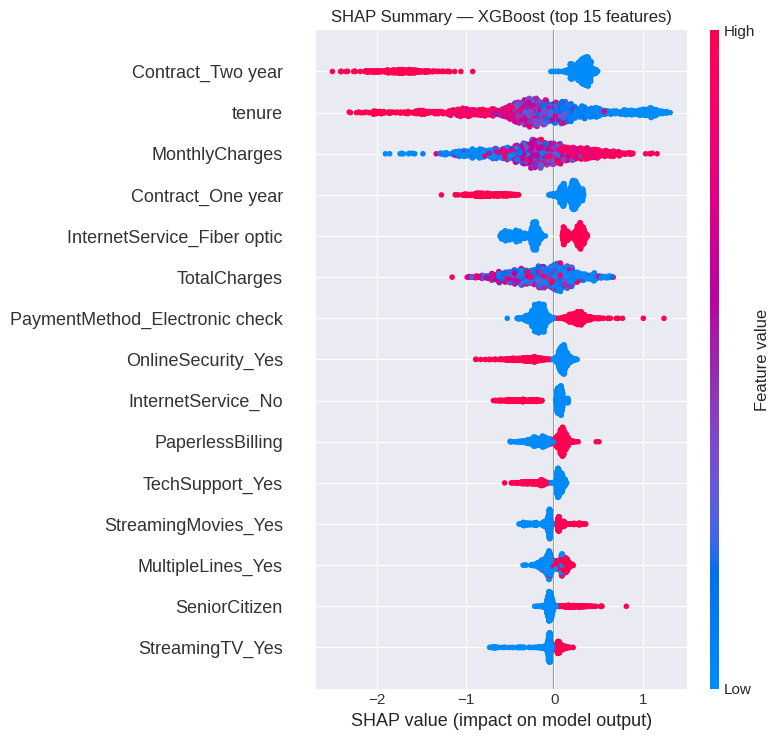

shap_global.png [saved]

--- Top 10 Features by Mean |SHAP| ---
Feature                                   Mean |SHAP|
------------------------------------------------------
Contract_Two year                              0.6442
tenure                                         0.5288
MonthlyCharges                                 0.3884
Contract_One year                              0.2969
InternetService_Fiber optic                    0.2854
TotalCharges                                   0.2528
PaymentMethod_Electronic check                 0.2140
OnlineSecurity_Yes                             0.1612
InternetService_No                             0.1336
PaperlessBilling                               0.1253


In [15]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# global: beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot",
                  max_display=15, show=False)
plt.title("SHAP Summary — XGBoost (top 15 features)")
plt.tight_layout()
plt.savefig("shap_global.png", dpi=120)
plt.show()
print("shap_global.png [saved]")

# top 10 mean |SHAP| table
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print("\n--- Top 10 Features by Mean |SHAP| ---")
print(f"{'Feature':<40} {'Mean |SHAP|':>12}")
print("-" * 54)
for feat, val in mean_shap.head(10).items():
    print(f"{feat:<40} {val:>12.4f}")


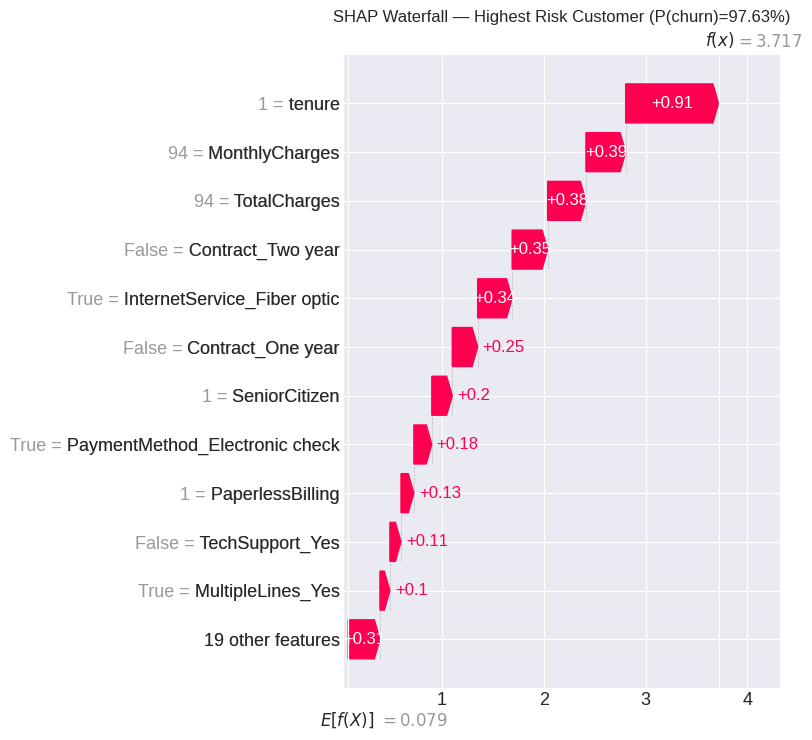

shap_local.png [saved]

--- Riskiest customer profile ---
  tenure                                   1
  MonthlyCharges                           94.0
  TotalCharges                             94.0
  Contract_Two year                        False
  Contract_One year                        False
  InternetService_Fiber optic              True
  PaymentMethod_Electronic check           True

  Actual churn: 1
  Predicted P(churn): 97.63%


In [16]:
# find the customer with highest predicted churn probability
riskiest_idx = np.argmax(y_prob_xgb)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[riskiest_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[riskiest_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.title(f"SHAP Waterfall — Highest Risk Customer (P(churn)={y_prob_xgb[riskiest_idx]:.2%})")
plt.tight_layout()
plt.savefig("shap_local.png", dpi=120)
plt.show()
print("shap_local.png [saved]")

# print that customer's key features
print("\n--- Riskiest customer profile ---")
profile_row = X_test.iloc[riskiest_idx]
key_features = ["tenure", "MonthlyCharges", "TotalCharges",
                "Contract_Two year", "Contract_One year",
                "InternetService_Fiber optic", "PaymentMethod_Electronic check"]
for f in key_features:
    print(f"  {f:<40} {profile_row[f]}")
print(f"\n  Actual churn: {y_test.iloc[riskiest_idx]}")
print(f"  Predicted P(churn): {y_prob_xgb[riskiest_idx]:.2%}")


# 7. Conclusions

**Model performance — XGBoost at threshold 0.23 (FN cost = 5× FP):**

| Metric | Baseline LR (0.50) | XGBoost (0.23) |
|---|---|---|
| ROC-AUC | 0.8446 | 0.8435 |
| Recall (churn) | 56.4% | **93.9%** |
| FN (missed churners) | 163 | **23** |
| Total business cost | 1,052 | **589** |

**Key drivers (SHAP global):**

1. **Contract type** (SHAP = 0.644) — the single strongest predictor. Month-to-month customers without a long-term contract are the core at-risk group.
2. **Tenure** (SHAP = 0.529) — customers with tenure < 18 months churn disproportionately. Early-stage retention is the highest-leverage window.
3. **Monthly charges + Fiber optic** (SHAP = 0.388 / 0.285) — premium services drive churn when not anchored by a contract.
4. **Electronic check payment** (SHAP = 0.214) — 45.3% churn rate; likely a proxy for month-to-month, low-commitment customers.

**Local SHAP — extreme case (P(churn) = 97.63%, actual: churned):**  
Tenure = 1 month, monthly charge = $94, fiber optic, electronic check, no contract — all top risk factors active simultaneously. The model correctly identifies this as near-certain churn from the base rate of 7.9%.

**Segmentation (K-Means, k=2):**  
Cluster 1 — high-spend ($77/month avg) — churns at 31.9% vs 7.2% for Cluster 0 (basic plan, $21/month). Retention budget should target Cluster 1 exclusively.

**Recommendation:** prioritize month-to-month fiber optic customers in their first 12 months. Offer contract upgrades with early-tenure incentives — this addresses all top 4 SHAP drivers simultaneously.
